# 01 — Garman–Kohlhagen (FX Black–Scholes)

Implements the analytical closed-form pricing of European FX options (Garman–Kohlhagen).

## Correspondence with the paper
- Analytical model (risk-neutral pricing for FX)
- Closed-form pricing formula (d1/d2)
- Sensitivity analysis: spot & volatility

## Outputs
- Call & Put prices
- Delta & Vega
- Price curves vs spot and volatility

In [2]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project root added:", project_root)

Project root added: c:\Users\rayzu\Pictures\fx-option-pricing-ml


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.bs_fx import garman_kohlhagen_price, delta, vega

S, K, T = 1.10, 1.10, 1.0
rd, rf = 0.02, 0.01
sigma = 0.03

call = garman_kohlhagen_price(S, K, T, rd, rf, sigma, option="call")
put  = garman_kohlhagen_price(S, K, T, rd, rf, sigma, option="put")

print("Call:", call)
print("Put :", put)
print("Delta(call):", delta(S, K, T, rd, rf, sigma, option="call"))
print("Vega:", vega(S, K, T, rd, rf, sigma))

Call: 0.01910073492507236
Put : 0.008264458438418276
Delta(call): 0.6298747222424818
Vega: 0.4088951924501521


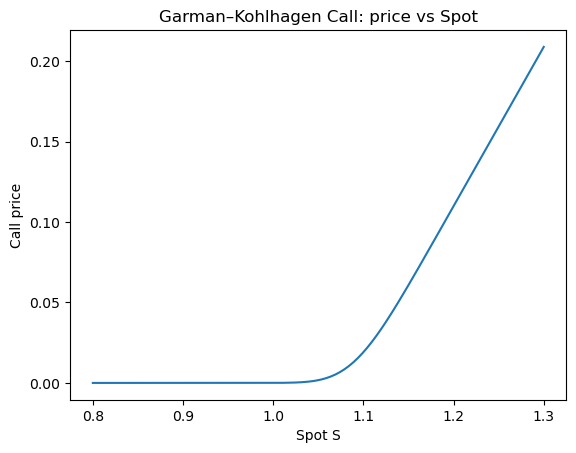

In [7]:
spots = np.linspace(0.8, 1.3, 200)
prices_spot = garman_kohlhagen_price(spots, K, T, rd, rf, sigma, option="call")

plt.figure()
plt.plot(spots, prices_spot)
plt.xlabel("Spot S")
plt.ylabel("Call price")
plt.title("Garman–Kohlhagen Call: price vs Spot")
plt.savefig("../results/figures/gk_price_vs_spot.png", dpi=300)
plt.show()

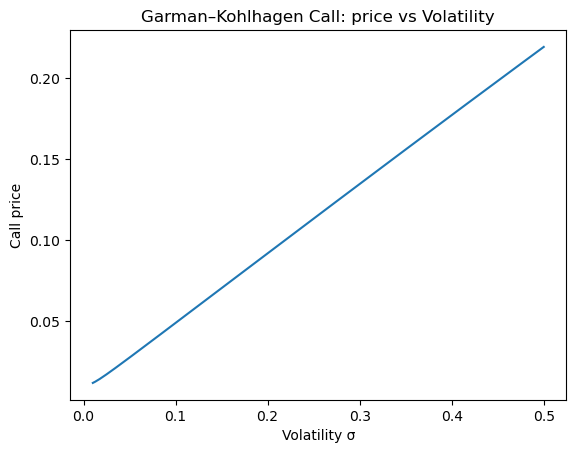

In [8]:
vols = np.linspace(0.01, 0.50, 200)
prices_vol = garman_kohlhagen_price(S, K, T, rd, rf, vols, option="call")

plt.figure()
plt.plot(vols, prices_vol)
plt.xlabel("Volatility σ")
plt.ylabel("Call price")
plt.title("Garman–Kohlhagen Call: price vs Volatility")
plt.savefig("../results/figures/gk_price_vs_volatility.png", dpi=300)
plt.show()

In [11]:
grid_S = [0.9, 1.0, 1.1, 1.2]
grid_sigma = [0.02, 0.05, 0.10]

rows = []
for s in grid_S:
    for sig in grid_sigma:
        rows.append({
            "S": s,
            "sigma": sig,
            "call": float(garman_kohlhagen_price(s, K, T, rd, rf, sig, "call")),
            "put":  float(garman_kohlhagen_price(s, K, T, rd, rf, sig, "put")),
        })

df=pd.DataFrame(rows)
df.to_csv("../results/tables/gk_price_grid.csv", index=False)
print(df)

      S  sigma          call           put
0   0.9   0.02  1.530222e-24  1.871737e-01
1   0.9   0.05  7.878234e-07  1.871745e-01
2   0.9   0.10  1.063752e-03  1.882374e-01
3   1.0   0.02  4.405851e-08  8.816875e-02
4   1.0   0.05  9.303343e-04  8.909904e-02
5   1.0   0.10  1.129050e-02  9.945921e-02
6   1.1   0.02  1.512291e-02  4.286629e-03
7   1.1   0.05  2.746205e-02  1.662577e-02
8   1.1   0.10  4.884668e-02  3.801041e-02
9   1.2   0.02  1.098413e-01  2.668319e-09
10  1.2   0.05  1.104042e-01  5.629886e-04
11  1.2   0.10  1.198121e-01  9.970883e-03


# Discussion

The Garman–Kohlhagen model extends Black–Scholes to foreign exchange by incorporating
two interest rates (domestic and foreign). This reflects the cost of carry between
currencies.

## Interpretation

- Option value increases with spot price (convex relationship).
- Vega confirms sensitivity to volatility, consistent with theoretical expectations.
- Delta reflects the foreign discount factor impact.

## Economic meaning

The model assumes:
- Constant volatility
- Lognormal FX dynamics
- No arbitrage and frictionless markets

While analytically elegant, it cannot capture volatility smiles observed in FX markets.

## Limitations

- Constant volatility assumption
- No stochastic interest rates
- No jumps or regime shifts

These motivate numerical and ML-based approaches explored in subsequent notebooks.

## Reproducibility

All experiments were performed with:
- Random seed fixed
- Deterministic splits
- Explicit parameter ranges

This ensures full reproducibility of the results.